# Simulação da desambiguação sequencial de ativos

## Objetivo

Avaliar, sob níveis controlados de incerteza posicional, se a associação sequencial baseada em HMM e no grafo de movimentação $G_{\mathrm{mov}}$ reduz identificações incorretas de válvulas visualmente idênticas em comparação com uma associação espacial independente.

## Hipóteses

1. Quando a posição observada for ambígua, mas o histórico de inspeções e o grafo fornecerem informações úteis, o HMM deverá apresentar maior acurácia que a associação espacial independente.

2. A aplicação dos limiares de confiança e de separação entre candidatos deverá reduzir as identificações incorretas, embora também diminua a quantidade de situações em que o sistema fornece uma identidade.

3. Em uma situação perfeitamente simétrica, na qual posição e histórico não diferenciam dois ativos, o sistema deverá manter a ambiguidade e suspender a identificação.

## Limites da simulação

A simulação avalia apenas a camada de desambiguação sequencial da arquitetura. As posições 3D e suas incertezas serão geradas sinteticamente como se fossem resultados das etapas anteriores. Portanto, o experimento não avalia detecção visual, profundidade, VIO, UWB, EKF, desempenho da interface de RA ou operação em ambiente offshore.

## 1. Definição geométrica da planta sintética

A planta será representada em metros, utilizando os eixos $x$, $y$ e $z$. O eixo $x$ acompanha o comprimento do módulo central, o eixo $y$ representa a separação entre seus dois lados e o eixo $z$ representa a altura.

O módulo de equipamentos ocupa a região entre $x=0$ m e $x=12$ m e entre $y=-1$ m e $y=1$ m. Essa região é considerada não atravessável.

O corredor superior tem sua linha central em $y=2$ m, enquanto o corredor inferior tem sua linha central em $y=-2$ m. Os dois corredores são conectados somente pelas extremidades, em $x=-1$ m e $x=13$ m.

As seis válvulas serão instaladas nas duas faces do módulo central. Os pares de válvulas opostas estarão separados por 2 m em linha reta, enquanto válvulas consecutivas do mesmo lado estarão separadas por 4 m.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

## 2. Construção do grafo de movimentação

O grafo $G_{\mathrm{mov}}$ representa os deslocamentos permitidos ao redor do módulo central. Inicialmente, serão definidos apenas os pontos de passagem dos corredores. As válvulas serão acrescentadas posteriormente.

In [2]:
pontos_passagem = {
    "S0": (-1.0,  2.0),
    "S1": ( 2.0,  2.0),
    "S2": ( 6.0,  2.0),
    "S3": (10.0,  2.0),
    "S4": (13.0,  2.0),

    "I0": (-1.0, -2.0),
    "I1": ( 2.0, -2.0),
    "I2": ( 6.0, -2.0),
    "I3": (10.0, -2.0),
    "I4": (13.0, -2.0),
}

pontos_passagem

{'S0': (-1.0, 2.0),
 'S1': (2.0, 2.0),
 'S2': (6.0, 2.0),
 'S3': (10.0, 2.0),
 'S4': (13.0, 2.0),
 'I0': (-1.0, -2.0),
 'I1': (2.0, -2.0),
 'I2': (6.0, -2.0),
 'I3': (10.0, -2.0),
 'I4': (13.0, -2.0)}

In [3]:
G_mov = nx.Graph()

for nome, coordenada in pontos_passagem.items():
    G_mov.add_node(
        nome,
        tipo="passagem",
        posicao=coordenada
    )

print("Quantidade de nós:", G_mov.number_of_nodes())
print("Quantidade de ligações:", G_mov.number_of_edges())
print("Dados do nó S1:", G_mov.nodes["S1"])

Quantidade de nós: 10
Quantidade de ligações: 0
Dados do nó S1: {'tipo': 'passagem', 'posicao': (2.0, 2.0)}


In [4]:
ligacoes_passagem = [
    ("S0", "S1"),
    ("S1", "S2"),
    ("S2", "S3"),
    ("S3", "S4"),

    ("I0", "I1"),
    ("I1", "I2"),
    ("I2", "I3"),
    ("I3", "I4"),

    ("S0", "I0"),
    ("S4", "I4"),
]

for origem, destino in ligacoes_passagem:
    x1, y1 = G_mov.nodes[origem]["posicao"]
    x2, y2 = G_mov.nodes[destino]["posicao"]

    comprimento = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5

    G_mov.add_edge(
        origem,
        destino,
        comprimento=comprimento
    )

print("Quantidade de nós:", G_mov.number_of_nodes())
print("Quantidade de ligações:", G_mov.number_of_edges())
print("O grafo está conectado?", nx.is_connected(G_mov))

Quantidade de nós: 10
Quantidade de ligações: 10
O grafo está conectado? True


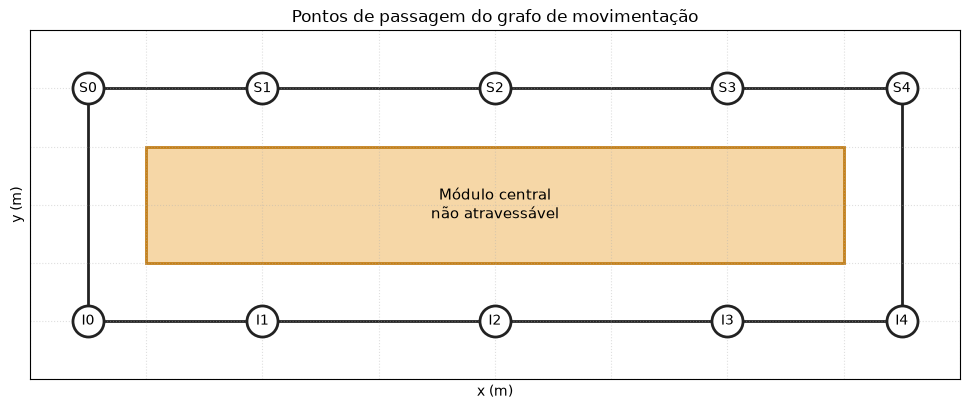

In [5]:
posicoes_grafo = nx.get_node_attributes(G_mov, "posicao")

fig, ax = plt.subplots(figsize=(12, 5))

modulo_central = plt.Rectangle(
    (0, -1),
    12,
    2,
    facecolor="#f6d7a7",
    edgecolor="#c47f17",
    linewidth=2
)

ax.add_patch(modulo_central)

nx.draw_networkx_edges(
    G_mov,
    pos=posicoes_grafo,
    ax=ax,
    width=2,
    edge_color="#222222"
)

nx.draw_networkx_nodes(
    G_mov,
    pos=posicoes_grafo,
    ax=ax,
    node_size=500,
    node_color="white",
    edgecolors="#222222",
    linewidths=2
)

nx.draw_networkx_labels(
    G_mov,
    pos=posicoes_grafo,
    ax=ax,
    font_size=10
)

ax.text(
    6,
    0,
    "Módulo central\nnão atravessável",
    ha="center",
    va="center",
    fontsize=11
)

ax.set_title("Pontos de passagem do grafo de movimentação")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_xlim(-2, 14)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)
ax.axis("on")

plt.show()

## 3. Cadastro das válvulas

Cada válvula possui uma identidade, uma posição 3D cadastrada e um ponto de passagem pelo qual o operador consegue acessá-la. Todas pertencem à mesma classe visual.

In [6]:
ativos = {
    "V1": {
        "posicao_3d": (2.0,  1.0, 1.2),
        "ponto_passagem": "S1"
    },
    "V3": {
        "posicao_3d": (6.0,  1.0, 1.2),
        "ponto_passagem": "S2"
    },
    "V5": {
        "posicao_3d": (10.0, 1.0, 1.2),
        "ponto_passagem": "S3"
    },

    "V2": {
        "posicao_3d": (2.0, -1.0, 1.2),
        "ponto_passagem": "I1"
    },
    "V4": {
        "posicao_3d": (6.0, -1.0, 1.2),
        "ponto_passagem": "I2"
    },
    "V6": {
        "posicao_3d": (10.0, -1.0, 1.2),
        "ponto_passagem": "I3"
    },
}

for identidade, dados in ativos.items():
    x, y, z = dados["posicao_3d"]
    ponto_passagem = dados["ponto_passagem"]

    G_mov.add_node(
        identidade,
        tipo="ativo",
        classe="valvula",
        posicao=(x, y),
        posicao_3d=(x, y, z)
    )

    xp, yp = G_mov.nodes[ponto_passagem]["posicao"]

    distancia_aproximacao = (
        (x - xp) ** 2 + (y - yp) ** 2
    ) ** 0.5

    G_mov.add_edge(
        identidade,
        ponto_passagem,
        comprimento=distancia_aproximacao
    )

ativos_no_grafo = [
    nome
    for nome, dados in G_mov.nodes(data=True)
    if dados["tipo"] == "ativo"
]

print("Quantidade total de nós:", G_mov.number_of_nodes())
print("Quantidade total de ligações:", G_mov.number_of_edges())
print("Ativos cadastrados:", ativos_no_grafo)
print("O grafo está conectado?", nx.is_connected(G_mov))

Quantidade total de nós: 16
Quantidade total de ligações: 16
Ativos cadastrados: ['V1', 'V3', 'V5', 'V2', 'V4', 'V6']
O grafo está conectado? True


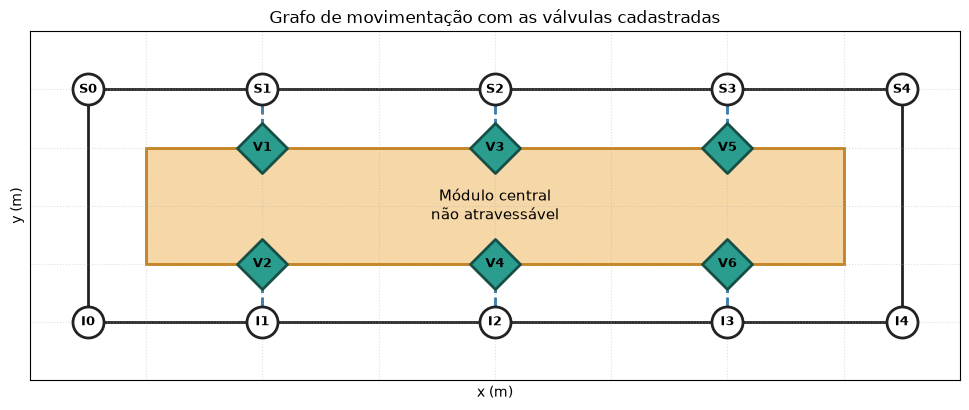

In [7]:
posicoes_completas = nx.get_node_attributes(G_mov, "posicao")

nos_passagem = [
    nome
    for nome, dados in G_mov.nodes(data=True)
    if dados["tipo"] == "passagem"
]

nos_ativos = [
    nome
    for nome, dados in G_mov.nodes(data=True)
    if dados["tipo"] == "ativo"
]

arestas_acesso = [
    (origem, destino)
    for origem, destino in G_mov.edges()
    if (
        G_mov.nodes[origem]["tipo"] == "ativo"
        or G_mov.nodes[destino]["tipo"] == "ativo"
    )
]

arestas_deslocamento = [
    (origem, destino)
    for origem, destino in G_mov.edges()
    if (origem, destino) not in arestas_acesso
]

fig, ax = plt.subplots(figsize=(12, 5))

modulo_central = plt.Rectangle(
    (0, -1),
    12,
    2,
    facecolor="#f6d7a7",
    edgecolor="#c47f17",
    linewidth=2
)

ax.add_patch(modulo_central)

nx.draw_networkx_edges(
    G_mov,
    pos=posicoes_completas,
    edgelist=arestas_deslocamento,
    ax=ax,
    width=2,
    edge_color="#222222"
)

nx.draw_networkx_edges(
    G_mov,
    pos=posicoes_completas,
    edgelist=arestas_acesso,
    ax=ax,
    width=2,
    edge_color="#3076a8",
    style="dashed"
)

nx.draw_networkx_nodes(
    G_mov,
    pos=posicoes_completas,
    nodelist=nos_passagem,
    ax=ax,
    node_size=500,
    node_color="white",
    edgecolors="#222222",
    linewidths=2
)

nx.draw_networkx_nodes(
    G_mov,
    pos=posicoes_completas,
    nodelist=nos_ativos,
    ax=ax,
    node_size=650,
    node_color="#2a9d8f",
    edgecolors="#174f47",
    linewidths=2,
    node_shape="D"
)

nx.draw_networkx_labels(
    G_mov,
    pos=posicoes_completas,
    ax=ax,
    font_size=9,
    font_weight="bold"
)

ax.text(
    6,
    0,
    "Módulo central\nnão atravessável",
    ha="center",
    va="center",
    fontsize=11
)

ax.set_title("Grafo de movimentação com as válvulas cadastradas")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_xlim(-2, 14)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)
ax.axis("on")

plt.show()

In [8]:
pares_teste = [
    ("V1", "V3"),
    ("V1", "V4"),
    ("V1", "V2"),
    ("V3", "V4"),
    ("V5", "V6"),
]

for origem, destino in pares_teste:
    posicao_origem = G_mov.nodes[origem]["posicao_3d"]
    posicao_destino = G_mov.nodes[destino]["posicao_3d"]

    distancia_reta = sum(
        (a - b) ** 2
        for a, b in zip(posicao_origem, posicao_destino)
    ) ** 0.5

    distancia_grafo = nx.shortest_path_length(
        G_mov,
        source=origem,
        target=destino,
        weight="comprimento"
    )

    caminho = nx.shortest_path(
        G_mov,
        source=origem,
        target=destino,
        weight="comprimento"
    )

    print(f"{origem} → {destino}")
    print(f"  Distância em linha reta: {distancia_reta:.2f} m")
    print(f"  Distância pelo grafo:    {distancia_grafo:.2f} m")
    print(f"  Caminho: {' → '.join(caminho)}")
    print()

V1 → V3
  Distância em linha reta: 4.00 m
  Distância pelo grafo:    6.00 m
  Caminho: V1 → S1 → S2 → V3

V1 → V4
  Distância em linha reta: 4.47 m
  Distância pelo grafo:    16.00 m
  Caminho: V1 → S1 → S0 → I0 → I1 → I2 → V4

V1 → V2
  Distância em linha reta: 2.00 m
  Distância pelo grafo:    12.00 m
  Caminho: V1 → S1 → S0 → I0 → I1 → V2

V3 → V4
  Distância em linha reta: 2.00 m
  Distância pelo grafo:    20.00 m
  Caminho: V3 → S2 → S1 → S0 → I0 → I1 → I2 → V4

V5 → V6
  Distância em linha reta: 2.00 m
  Distância pelo grafo:    12.00 m
  Caminho: V5 → S3 → S4 → I4 → I3 → V6



## 4. Sequências verdadeiras de inspeção

Cada sequência representa a ordem real em que as válvulas foram inspecionadas. Essas identidades serão utilizadas apenas como gabarito para gerar as observações e calcular as métricas. Os métodos de associação não receberão as identidades verdadeiras.

In [9]:
sequencias_inspecao = {
    "circuito_horario": [
        "V1", "V3", "V5", "V6", "V4", "V2"
    ],

    "circuito_antihorario": [
        "V2", "V4", "V6", "V5", "V3", "V1"
    ],

    "troca_central_longa": [
        "V1", "V3", "V4", "V2", "V6", "V5"
    ],

    "inspecao_com_saltos": [
        "V1", "V5", "V3", "V2", "V4", "V6"
    ],
}

conjunto_ativos = set(ativos.keys())

for nome, sequencia in sequencias_inspecao.items():
    assert len(sequencia) == len(ativos)
    assert set(sequencia) == conjunto_ativos

    distancia_total = sum(
        nx.shortest_path_length(
            G_mov,
            source=origem,
            target=destino,
            weight="comprimento"
        )
        for origem, destino in zip(
            sequencia[:-1],
            sequencia[1:]
        )
    )

    print(f"{nome}:")
    print(f"  Sequência: {' → '.join(sequencia)}")
    print(f"  Distância total: {distancia_total:.2f} m")
    print()

circuito_horario:
  Sequência: V1 → V3 → V5 → V6 → V4 → V2
  Distância total: 36.00 m

circuito_antihorario:
  Sequência: V2 → V4 → V6 → V5 → V3 → V1
  Distância total: 36.00 m

troca_central_longa:
  Sequência: V1 → V3 → V4 → V2 → V6 → V5
  Distância total: 54.00 m

inspecao_com_saltos:
  Sequência: V1 → V5 → V3 → V2 → V4 → V6
  Distância total: 44.00 m



## 5. Simulação das observações 3D

Para cada inspeção, a posição observada será obtida acrescentando um erro aleatório à posição verdadeira do ativo:

$$
\mathbf{o}_t = \mathbf{p}_{s_t} + \boldsymbol{\varepsilon}_t
$$

onde $\mathbf{p}_{s_t}$ é a posição cadastrada do ativo verdadeiro e $\boldsymbol{\varepsilon}_t$ representa o erro acumulado das etapas anteriores da arquitetura. Nesta primeira configuração demonstrativa, a incerteza será representada por uma matriz de covariância diagonal.

In [10]:
import numpy as np
import pandas as pd

desvios_padrao = np.array([
    0.5,   # incerteza no eixo x, em metros
    1.0,   # incerteza no eixo y, em metros
    0.1    # incerteza no eixo z, em metros
])

covariancia_observacao = np.diag(
    desvios_padrao ** 2
)

covariancia_df = pd.DataFrame(
    covariancia_observacao,
    index=["x", "y", "z"],
    columns=["x", "y", "z"]
)

covariancia_df

,x,y,z
x,0.25,0.0,0.00
y,0.00,1.0,0.00
z,0.00,0.0,0.01


In [11]:
def simular_observacoes(
    sequencia,
    covariancia,
    semente
):
    gerador = np.random.default_rng(semente)
    registros = []

    for instante, identidade_real in enumerate(
        sequencia,
        start=1
    ):
        posicao_real = np.array(
            ativos[identidade_real]["posicao_3d"],
            dtype=float
        )

        erro = gerador.multivariate_normal(
            mean=np.zeros(3),
            cov=covariancia
        )

        posicao_observada = posicao_real + erro

        registros.append({
            "t": instante,
            "ativo_real": identidade_real,

            "x_real": posicao_real[0],
            "y_real": posicao_real[1],
            "z_real": posicao_real[2],

            "x_observado": posicao_observada[0],
            "y_observado": posicao_observada[1],
            "z_observado": posicao_observada[2],

            "erro_m": np.linalg.norm(erro)
        })

    return pd.DataFrame(registros)

In [12]:
observacoes_exemplo = simular_observacoes(
    sequencia=sequencias_inspecao["circuito_horario"],
    covariancia=covariancia_observacao,
    semente=42
)

observacoes_exemplo.round(3)

,t,ativo_real,x_real,y_real,z_real,x_observado,y_observado,z_observado,erro_m
0,1,V1,2.0,1.0,1.2,1.480,1.305,1.275,0.607
1,2,V3,6.0,1.0,1.2,5.024,1.941,1.070,1.361
2,3,V5,10.0,1.0,1.2,9.842,1.128,1.198,0.203
3,4,V6,10.0,-1.0,1.2,10.440,-1.853,1.278,0.963
4,5,V4,6.0,-1.0,1.2,6.564,-0.934,1.247,0.569
5,6,V2,2.0,-1.0,1.2,2.184,-1.859,1.104,0.884


## 6. Associação espacial independente

A associação espacial independente analisa cada observação isoladamente, sem utilizar o histórico das inspeções ou o grafo de movimentação. O ativo escolhido é aquele que apresenta a menor distância de Mahalanobis em relação à posição observada.

A distância de Mahalanobis considera a incerteza diferente em cada direção:

$$
d_M(\mathbf{o},\mathbf{p}_j)
=
\sqrt{
(\mathbf{o}-\mathbf{p}_j)^\top
\Sigma^{-1}
(\mathbf{o}-\mathbf{p}_j)
}
$$

In [13]:
def calcular_distancia_mahalanobis(
    observacao,
    posicao_ativo,
    covariancia
):
    diferenca = observacao - posicao_ativo
    inversa_covariancia = np.linalg.inv(covariancia)

    distancia_quadrada = (
        diferenca.T
        @ inversa_covariancia
        @ diferenca
    )

    return float(np.sqrt(distancia_quadrada))

In [14]:
linha_t2 = observacoes_exemplo.iloc[1]

observacao_t2 = np.array([
    linha_t2["x_observado"],
    linha_t2["y_observado"],
    linha_t2["z_observado"]
])

distancias_t2 = {}

for identidade, dados in ativos.items():
    posicao_ativo = np.array(
        dados["posicao_3d"],
        dtype=float
    )

    distancias_t2[identidade] = (
        calcular_distancia_mahalanobis(
            observacao=observacao_t2,
            posicao_ativo=posicao_ativo,
            covariancia=covariancia_observacao
        )
    )

pd.Series(
    distancias_t2,
    name="distancia_mahalanobis"
).sort_values()

V3     2.527226
V4     3.761533
V1     6.258619
V2     6.850735
V5    10.079853
V6    10.457805
Name: distancia_mahalanobis, dtype: float64

In [15]:
def associar_independentemente(
    observacoes,
    ativos,
    covariancia
):
    predicoes = []

    for _, linha in observacoes.iterrows():
        observacao = np.array([
            linha["x_observado"],
            linha["y_observado"],
            linha["z_observado"]
        ])

        distancias = {}

        for identidade, dados in ativos.items():
            posicao_ativo = np.array(
                dados["posicao_3d"],
                dtype=float
            )

            distancias[identidade] = (
                calcular_distancia_mahalanobis(
                    observacao=observacao,
                    posicao_ativo=posicao_ativo,
                    covariancia=covariancia
                )
            )

        ranking = sorted(
            distancias.items(),
            key=lambda item: item[1]
        )

        melhor_ativo, menor_distancia = ranking[0]
        segundo_ativo, segunda_distancia = ranking[1]

        predicoes.append({
            "predicao_espacial": melhor_ativo,
            "distancia_menor": menor_distancia,
            "segundo_candidato": segundo_ativo,
            "distancia_segunda": segunda_distancia
        })

    resultado = pd.concat(
        [
            observacoes.reset_index(drop=True),
            pd.DataFrame(predicoes)
        ],
        axis=1
    )

    resultado["acerto_espacial"] = (
        resultado["ativo_real"]
        == resultado["predicao_espacial"]
    )

    return resultado

In [16]:
resultado_espacial_exemplo = associar_independentemente(
    observacoes=observacoes_exemplo,
    ativos=ativos,
    covariancia=covariancia_observacao
)

colunas_exibidas = [
    "t",
    "ativo_real",
    "predicao_espacial",
    "segundo_candidato",
    "distancia_menor",
    "distancia_segunda",
    "acerto_espacial"
]

display(
    resultado_espacial_exemplo[
        colunas_exibidas
    ].round(3)
)

acuracia_espacial = (
    resultado_espacial_exemplo[
        "acerto_espacial"
    ].mean()
)

print(
    f"Acurácia espacial neste exemplo: "
    f"{acuracia_espacial:.1%}"
)

,t,ativo_real,predicao_espacial,segundo_candidato,distancia_menor,distancia_segunda,acerto_espacial
0,1,V1,V1,V2,1.318,2.638,True
1,2,V3,V3,V4,2.527,3.762,True
2,3,V5,V5,V6,0.342,2.151,True
3,4,V6,V6,V5,1.451,3.085,True
4,5,V4,V4,V3,1.222,2.287,True
5,6,V2,V2,V1,1.339,3.038,True


Acurácia espacial neste exemplo: 100.0%


## 7. Probabilidades de emissão

A probabilidade de emissão representa a compatibilidade espacial entre uma observação e cada identidade candidata. Ela é calculada a partir do quadrado da distância de Mahalanobis:

$$
b_j(\mathbf{o}_t)
=
\frac{
\exp\left(-\frac{1}{2}d_M^2(\mathbf{o}_t,\mathbf{p}_j)\right)
}{
\sum_k
\exp\left(-\frac{1}{2}d_M^2(\mathbf{o}_t,\mathbf{p}_k)\right)
}
$$

As probabilidades são normalizadas para que sua soma seja igual a 1. Nesta etapa, elas ainda utilizam somente a posição observada, sem considerar o histórico ou o grafo.

In [17]:
def calcular_probabilidades_emissao(
    observacao,
    ativos,
    covariancia
):
    identidades = list(ativos.keys())
    log_compatibilidades = []

    for identidade in identidades:
        posicao_ativo = np.array(
            ativos[identidade]["posicao_3d"],
            dtype=float
        )

        distancia = calcular_distancia_mahalanobis(
            observacao=observacao,
            posicao_ativo=posicao_ativo,
            covariancia=covariancia
        )

        log_compatibilidade = -0.5 * distancia ** 2
        log_compatibilidades.append(log_compatibilidade)

    log_compatibilidades = np.array(
        log_compatibilidades
    )

    log_compatibilidades -= (
        log_compatibilidades.max()
    )

    compatibilidades = np.exp(
        log_compatibilidades
    )

    probabilidades = (
        compatibilidades
        / compatibilidades.sum()
    )

    return pd.Series(
        probabilidades,
        index=identidades,
        name="probabilidade_emissao"
    )

In [18]:
probabilidades_t2 = calcular_probabilidades_emissao(
    observacao=observacao_t2,
    ativos=ativos,
    covariancia=covariancia_observacao
)

display(
    probabilidades_t2
    .sort_values(ascending=False)
    .to_frame()
    .round(6)
)

print(
    "Soma das probabilidades:",
    probabilidades_t2.sum()
)

,probabilidade_emissao
V3,0.979789
V4,0.020211
V1,0.000000
V2,0.000000
V5,0.000000
V6,0.000000


Soma das probabilidades: 0.9999999999999998


## 8. Caminhos e probabilidades de transição

As probabilidades de transição entre as identidades serão derivadas dos caminhos existentes em $G_{\mathrm{mov}}$. Os pontos de passagem participam do cálculo do percurso, mas não produzem observações de ativos.

Cada instante da simulação representa uma nova inspeção já estabilizada. Por isso, nesta implementação, as transições imediatas de um ativo para ele mesmo serão inicialmente definidas como zero.

In [19]:
def calcular_comprimento_caminho(
    grafo,
    caminho
):
    return sum(
        grafo.edges[origem, destino]["comprimento"]
        for origem, destino in zip(
            caminho[:-1],
            caminho[1:]
        )
    )

In [20]:
maximo_arestas = 12

caminhos_v3_v4 = list(
    nx.all_simple_paths(
        G_mov,
        source="V3",
        target="V4",
        cutoff=maximo_arestas
    )
)

print(
    "Quantidade de caminhos simples entre V3 e V4:",
    len(caminhos_v3_v4)
)

for numero, caminho in enumerate(
    caminhos_v3_v4,
    start=1
):
    comprimento = calcular_comprimento_caminho(
        G_mov,
        caminho
    )

    print(f"\nCaminho {numero}:")
    print("  " + " → ".join(caminho))
    print(f"  Comprimento: {comprimento:.2f} m")

Quantidade de caminhos simples entre V3 e V4: 2

Caminho 1:
  V3 → S2 → S1 → S0 → I0 → I1 → I2 → V4
  Comprimento: 20.00 m

Caminho 2:
  V3 → S2 → S3 → S4 → I4 → I3 → I2 → V4
  Comprimento: 20.00 m


In [21]:
def construir_matriz_transicao(
    grafo,
    identidades,
    escala,
    maximo_arestas
):
    pesos = pd.DataFrame(
        0.0,
        index=identidades,
        columns=identidades
    )

    for origem in identidades:
        for destino in identidades:
            if origem == destino:
                continue

            caminhos = nx.all_simple_paths(
                grafo,
                source=origem,
                target=destino,
                cutoff=maximo_arestas
            )

            for caminho in caminhos:
                comprimento = (
                    calcular_comprimento_caminho(
                        grafo,
                        caminho
                    )
                )

                peso_caminho = np.exp(
                    -comprimento / escala
                )

                pesos.loc[origem, destino] += (
                    peso_caminho
                )

    somas_linhas = pesos.sum(axis=1)

    if (somas_linhas == 0).any():
        raise ValueError(
            "Existe um ativo sem transições possíveis."
        )

    matriz = pesos.div(
        somas_linhas,
        axis=0
    )

    return matriz

In [22]:
identidades_ativos = sorted(
    ativos.keys(),
    key=lambda identidade: int(identidade[1:])
)

escala_transicao = 8.0

matriz_transicao = construir_matriz_transicao(
    grafo=G_mov,
    identidades=identidades_ativos,
    escala=escala_transicao,
    maximo_arestas=maximo_arestas
)

display(
    matriz_transicao.round(3)
)

print(
    "Todas as linhas somam 1?",
    np.allclose(
        matriz_transicao.sum(axis=1),
        1.0
    )
)

print(
    "A diagonal é igual a zero?",
    np.allclose(
        np.diag(matriz_transicao),
        0.0
    )
)

,V1,V2,V3,V4,V5,V6
V1,0.000,0.181,0.348,0.132,0.222,0.117
V2,0.181,0.000,0.132,0.348,0.117,0.222
V3,0.323,0.123,0.000,0.109,0.323,0.123
V4,0.123,0.323,0.109,0.000,0.123,0.323
V5,0.222,0.117,0.348,0.132,0.000,0.181
V6,0.117,0.222,0.132,0.348,0.181,0.000


Todas as linhas somam 1? True
A diagonal é igual a zero? True


In [23]:
def construir_matriz_emissoes(
    observacoes,
    ativos,
    covariancia,
    identidades
):
    linhas = []

    for _, registro in observacoes.iterrows():
        observacao = np.array(
            [
                registro["x_observado"],
                registro["y_observado"],
                registro["z_observado"],
            ],
            dtype=float,
        )

        probabilidades = calcular_probabilidades_emissao(
            observacao=observacao,
            ativos=ativos,
            covariancia=covariancia,
        )

        linhas.append(
            probabilidades.reindex(identidades).to_numpy()
        )

    matriz_emissoes = pd.DataFrame(
        linhas,
        index=observacoes["t"].to_numpy(),
        columns=identidades,
    )

    matriz_emissoes.index.name = "t"

    return matriz_emissoes


matriz_emissoes_exemplo = construir_matriz_emissoes(
    observacoes=observacoes_exemplo,
    ativos=ativos,
    covariancia=covariancia_observacao,
    identidades=identidades_ativos,
)

display(matriz_emissoes_exemplo.round(6))

print(
    "Todas as linhas somam 1?",
    np.allclose(
        matriz_emissoes_exemplo.sum(axis=1),
        1.0,
    ),
)

,V1,V2,V3,V4,V5,V6
t,,,,,,
1,0.931466,0.068534,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.979789,0.020211,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.905139,0.094861
4,0.000000,0.000000,0.000000,0.000000,0.023984,0.976016
5,0.000000,0.000000,0.133780,0.866220,0.000000,0.000000
6,0.023693,0.976307,0.000000,0.000000,0.000000,0.000000


Todas as linhas somam 1? True


In [24]:
def executar_forward(
    matriz_emissoes,
    matriz_transicao,
    distribuicao_inicial
):
    identidades = list(matriz_emissoes.columns)

    emissoes = matriz_emissoes.loc[
        :,
        identidades
    ].to_numpy(dtype=float)

    transicoes = matriz_transicao.loc[
        identidades,
        identidades
    ].to_numpy(dtype=float)

    inicial = distribuicao_inicial.reindex(
        identidades
    ).to_numpy(dtype=float)

    posteriores = np.zeros_like(
        emissoes,
        dtype=float
    )

    alpha = inicial * emissoes[0]
    normalizador = alpha.sum()

    if normalizador <= 0:
        raise ValueError(
            "Não foi possível normalizar o primeiro instante."
        )

    posteriores[0] = alpha / normalizador

    for indice_tempo in range(1, len(emissoes)):
        distribuicao_predita = (
            posteriores[indice_tempo - 1]
            @ transicoes
        )

        alpha = (
            distribuicao_predita
            * emissoes[indice_tempo]
        )

        normalizador = alpha.sum()

        if normalizador <= 0:
            raise ValueError(
                f"Não foi possível normalizar o instante "
                f"{matriz_emissoes.index[indice_tempo]}."
            )

        posteriores[indice_tempo] = (
            alpha / normalizador
        )

    return pd.DataFrame(
        posteriores,
        index=matriz_emissoes.index,
        columns=identidades,
    )


distribuicao_inicial = pd.Series(
    1.0 / len(identidades_ativos),
    index=identidades_ativos,
    name="probabilidade_inicial",
)

posteriores_forward_exemplo = executar_forward(
    matriz_emissoes=matriz_emissoes_exemplo,
    matriz_transicao=matriz_transicao,
    distribuicao_inicial=distribuicao_inicial,
)

display(posteriores_forward_exemplo.round(6))

print(
    "Todas as linhas somam 1?",
    np.allclose(
        posteriores_forward_exemplo.sum(axis=1),
        1.0,
    ),
)

,V1,V2,V3,V4,V5,V6
t,,,,,,
1,0.931466,0.068534,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.990972,0.009028,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.960908,0.039092
4,0.000000,0.000000,0.000000,0.000000,0.000999,0.999001
5,0.000000,0.000000,0.055610,0.944390,0.000000,0.000000
6,0.010320,0.989680,0.000000,0.000000,0.000000,0.000000


Todas as linhas somam 1? True


In [25]:
resultado_comparacao_exemplo = (
    observacoes_exemplo[
        ["t", "ativo_real"]
    ]
    .set_index("t")
    .copy()
)

resultado_comparacao_exemplo["predicao_espacial"] = (
    resultado_espacial_exemplo
    .set_index("t")["predicao_espacial"]
)

resultado_comparacao_exemplo["predicao_forward"] = (
    posteriores_forward_exemplo.idxmax(axis=1)
)

resultado_comparacao_exemplo["confianca_espacial"] = (
    matriz_emissoes_exemplo.max(axis=1)
)

resultado_comparacao_exemplo["confianca_forward"] = (
    posteriores_forward_exemplo.max(axis=1)
)

resultado_comparacao_exemplo["acerto_espacial"] = (
    resultado_comparacao_exemplo["predicao_espacial"]
    == resultado_comparacao_exemplo["ativo_real"]
)

resultado_comparacao_exemplo["acerto_forward"] = (
    resultado_comparacao_exemplo["predicao_forward"]
    == resultado_comparacao_exemplo["ativo_real"]
)

display(
    resultado_comparacao_exemplo.round(
        {
            "confianca_espacial": 6,
            "confianca_forward": 6,
        }
    )
)

print(
    "Acurácia espacial:",
    f"{resultado_comparacao_exemplo['acerto_espacial'].mean():.1%}",
)

print(
    "Acurácia Forward:",
    f"{resultado_comparacao_exemplo['acerto_forward'].mean():.1%}",
)

,ativo_real,predicao_espacial,predicao_forward,confianca_espacial,confianca_forward,acerto_espacial,acerto_forward
t,,,,,,,
1,V1,V1,V1,0.931466,0.931466,True,True
2,V3,V3,V3,0.979789,0.990972,True,True
3,V5,V5,V5,0.905139,0.960908,True,True
4,V6,V6,V6,0.976016,0.999001,True,True
5,V4,V4,V4,0.866220,0.944390,True,True
6,V2,V2,V2,0.976307,0.989680,True,True


Acurácia espacial: 100.0%
Acurácia Forward: 100.0%


In [26]:
def converter_para_log(probabilidades):
    probabilidades = np.asarray(
        probabilidades,
        dtype=float,
    )

    log_probabilidades = np.full(
        probabilidades.shape,
        -np.inf,
        dtype=float,
    )

    np.log(
        probabilidades,
        out=log_probabilidades,
        where=probabilidades > 0,
    )

    return log_probabilidades


def executar_viterbi(
    matriz_emissoes,
    matriz_transicao,
    distribuicao_inicial,
):
    identidades = list(matriz_emissoes.columns)

    emissoes = matriz_emissoes.loc[
        :,
        identidades,
    ].to_numpy(dtype=float)

    transicoes = matriz_transicao.loc[
        identidades,
        identidades,
    ].to_numpy(dtype=float)

    inicial = distribuicao_inicial.reindex(
        identidades
    ).to_numpy(dtype=float)

    log_emissoes = converter_para_log(emissoes)
    log_transicoes = converter_para_log(transicoes)
    log_inicial = converter_para_log(inicial)

    quantidade_instantes, quantidade_estados = (
        emissoes.shape
    )

    melhores_escores = np.full(
        (quantidade_instantes, quantidade_estados),
        -np.inf,
        dtype=float,
    )

    predecessores = np.full(
        (quantidade_instantes, quantidade_estados),
        -1,
        dtype=int,
    )

    melhores_escores[0] = (
        log_inicial + log_emissoes[0]
    )

    for instante in range(1, quantidade_instantes):
        for destino in range(quantidade_estados):
            escores_candidatos = (
                melhores_escores[instante - 1]
                + log_transicoes[:, destino]
            )

            melhor_origem = int(
                np.argmax(escores_candidatos)
            )

            predecessores[
                instante,
                destino,
            ] = melhor_origem

            melhores_escores[
                instante,
                destino,
            ] = (
                escores_candidatos[melhor_origem]
                + log_emissoes[instante, destino]
            )

    ultimo_estado = int(
        np.argmax(melhores_escores[-1])
    )

    if not np.isfinite(
        melhores_escores[-1, ultimo_estado]
    ):
        raise ValueError(
            "Nenhuma sequência válida foi encontrada."
        )

    caminho_indices = [0] * quantidade_instantes
    caminho_indices[-1] = ultimo_estado

    for instante in range(
        quantidade_instantes - 1,
        0,
        -1,
    ):
        caminho_indices[instante - 1] = (
            predecessores[
                instante,
                caminho_indices[instante],
            ]
        )

    return pd.Series(
        [
            identidades[indice]
            for indice in caminho_indices
        ],
        index=matriz_emissoes.index,
        name="predicao_viterbi",
    )


predicoes_viterbi_exemplo = executar_viterbi(
    matriz_emissoes=matriz_emissoes_exemplo,
    matriz_transicao=matriz_transicao,
    distribuicao_inicial=distribuicao_inicial,
)

resultado_comparacao_exemplo[
    "predicao_viterbi"
] = predicoes_viterbi_exemplo

resultado_comparacao_exemplo[
    "acerto_viterbi"
] = (
    resultado_comparacao_exemplo["predicao_viterbi"]
    == resultado_comparacao_exemplo["ativo_real"]
)

display(
    resultado_comparacao_exemplo[
        [
            "ativo_real",
            "predicao_espacial",
            "predicao_forward",
            "predicao_viterbi",
            "acerto_viterbi",
        ]
    ]
)

print(
    "Sequência Viterbi:",
    " → ".join(predicoes_viterbi_exemplo),
)

print(
    "Acurácia Viterbi:",
    f"{resultado_comparacao_exemplo['acerto_viterbi'].mean():.1%}",
)

,ativo_real,predicao_espacial,predicao_forward,predicao_viterbi,acerto_viterbi
t,,,,,
1,V1,V1,V1,V1,True
2,V3,V3,V3,V3,True
3,V5,V5,V5,V5,True
4,V6,V6,V6,V6,True
5,V4,V4,V4,V4,True
6,V2,V2,V2,V2,True


Sequência Viterbi: V1 → V3 → V5 → V6 → V4 → V2
Acurácia Viterbi: 100.0%


In [27]:
def aplicar_regra_abstencao(
    matriz_probabilidades,
    limiar_confianca,
    limiar_separacao,
):
    resultados = []

    for instante, probabilidades in (
        matriz_probabilidades.iterrows()
    ):
        probabilidades_ordenadas = (
            probabilidades.sort_values(
                ascending=False
            )
        )

        primeiro_candidato = (
            probabilidades_ordenadas.index[0]
        )
        segundo_candidato = (
            probabilidades_ordenadas.index[1]
        )

        maior_probabilidade = float(
            probabilidades_ordenadas.iloc[0]
        )
        segunda_probabilidade = float(
            probabilidades_ordenadas.iloc[1]
        )

        separacao = (
            maior_probabilidade
            - segunda_probabilidade
        )

        aceito = bool(
            maior_probabilidade
            >= limiar_confianca
            and separacao
            >= limiar_separacao
        )

        resultados.append(
            {
                "t": instante,
                "primeiro_candidato": primeiro_candidato,
                "segundo_candidato": segundo_candidato,
                "confianca": maior_probabilidade,
                "separacao": separacao,
                "aceito": aceito,
                "decisao": (
                    primeiro_candidato
                    if aceito
                    else "ABSTENCAO"
                ),
            }
        )

    return (
        pd.DataFrame(resultados)
        .set_index("t")
    )


limiar_confianca_exemplo = 0.80
limiar_separacao_exemplo = 0.25

decisoes_forward_exemplo = (
    aplicar_regra_abstencao(
        matriz_probabilidades=(
            posteriores_forward_exemplo
        ),
        limiar_confianca=(
            limiar_confianca_exemplo
        ),
        limiar_separacao=(
            limiar_separacao_exemplo
        ),
    )
)

display(
    decisoes_forward_exemplo.round(
        {
            "confianca": 6,
            "separacao": 6,
        }
    )
)

,primeiro_candidato,segundo_candidato,confianca,separacao,aceito,decisao
t,,,,,,
1,V1,V2,0.931466,0.862933,True,V1
2,V3,V4,0.990972,0.981945,True,V3
3,V5,V6,0.960908,0.921816,True,V5
4,V6,V5,0.999001,0.998003,True,V6
5,V4,V3,0.944390,0.888781,True,V4
6,V2,V1,0.989680,0.979360,True,V2


In [28]:
probabilidades_teste_ambiguo = pd.DataFrame(
    [
        {
            "V1": 0.0,
            "V2": 0.0,
            "V3": 0.5,
            "V4": 0.5,
            "V5": 0.0,
            "V6": 0.0,
        }
    ],
    index=pd.Index(
        [0],
        name="t",
    ),
)

decisao_teste_ambiguo = aplicar_regra_abstencao(
    matriz_probabilidades=(
        probabilidades_teste_ambiguo
    ),
    limiar_confianca=(
        limiar_confianca_exemplo
    ),
    limiar_separacao=(
        limiar_separacao_exemplo
    ),
)

display(decisao_teste_ambiguo)

,primeiro_candidato,segundo_candidato,confianca,separacao,aceito,decisao
t,,,,,,
0,V4,V3,0.5,0.0,False,ABSTENCAO


In [29]:
def calcular_metricas_com_abstencao(
    decisoes,
    observacoes,
):
    identidades_reais = (
        observacoes
        .set_index("t")["ativo_real"]
        .reindex(decisoes.index)
    )

    aceitas = decisoes["aceito"].astype(bool)

    corretas = (
        aceitas
        & decisoes["decisao"].eq(
            identidades_reais
        )
    )

    incorretas = (
        aceitas
        & ~decisoes["decisao"].eq(
            identidades_reais
        )
    )

    quantidade_total = len(decisoes)
    quantidade_aceita = int(aceitas.sum())
    quantidade_abstida = (
        quantidade_total - quantidade_aceita
    )

    cobertura = (
        quantidade_aceita / quantidade_total
    )

    if quantidade_aceita > 0:
        acuracia_seletiva = (
            corretas.sum() / quantidade_aceita
        )
    else:
        acuracia_seletiva = np.nan

    return pd.Series(
        {
            "quantidade_total": quantidade_total,
            "quantidade_aceita": quantidade_aceita,
            "quantidade_abstida": quantidade_abstida,
            "cobertura": cobertura,
            "taxa_abstencao": 1.0 - cobertura,
            "acuracia_seletiva": acuracia_seletiva,
            "taxa_identificacoes_incorretas": (
                incorretas.sum()
                / quantidade_total
            ),
        }
    )


decisoes_espaciais_exemplo = (
    aplicar_regra_abstencao(
        matriz_probabilidades=(
            matriz_emissoes_exemplo
        ),
        limiar_confianca=(
            limiar_confianca_exemplo
        ),
        limiar_separacao=(
            limiar_separacao_exemplo
        ),
    )
)

metricas_abstencao_exemplo = pd.DataFrame(
    {
        "Espacial": (
            calcular_metricas_com_abstencao(
                decisoes=(
                    decisoes_espaciais_exemplo
                ),
                observacoes=observacoes_exemplo,
            )
        ),
        "Forward": (
            calcular_metricas_com_abstencao(
                decisoes=(
                    decisoes_forward_exemplo
                ),
                observacoes=observacoes_exemplo,
            )
        ),
    }
).T

display(
    metricas_abstencao_exemplo.round(3)
)

,quantidade_total,quantidade_aceita,quantidade_abstida,cobertura,taxa_abstencao,acuracia_seletiva,taxa_identificacoes_incorretas
Espacial,6.0,6.0,0.0,1.0,0.0,1.0,0.0
Forward,6.0,6.0,0.0,1.0,0.0,1.0,0.0


## Protocolo experimental de avaliação

A comparação principal será realizada entre a associação espacial independente e a inferência sequencial pelo algoritmo Forward. O Viterbi será avaliado separadamente como método de decodificação global da sequência.

A covariância-base das observações será escalada por fatores de ruído iguais a 0.50, 0.75, 1.00, 1.25, 1.50 e 2.00. Para um fator \(s\), será utilizada a covariância

$$
\Sigma_s = s^2 \Sigma_0
$$

As quatro sequências de inspeção serão avaliadas separadamente, evitando que resultados de trajetórias regulares e irregulares sejam misturados em uma única média.

Serão utilizados três conjuntos independentes de sementes:

- a semente 42 permanecerá apenas como verificação funcional;
- as sementes de 1000 a 1199 serão usadas para validação e análise de parâmetros;
- as sementes de 10000 a 10999 serão reservadas para a avaliação final.

As métricas sem abstenção serão a acurácia da associação espacial, do Forward e do Viterbi. Para decisões com abstenção, serão medidas cobertura, acurácia seletiva, taxa de abstenção e taxa de identificações incorretas.

Os limiares de confiança e separação não serão escolhidos usando os resultados finais. O conjunto de teste será utilizado somente depois que as decisões de parametrização estiverem definidas.

Também será executado um controle negativo perfeitamente simétrico, no qual posição e histórico não distinguem dois ativos. Nesse caso, o comportamento esperado é conservar a ambiguidade e não emitir uma identidade.

In [30]:
def executar_repeticao(
    nome_sequencia,
    sequencia,
    covariancia,
    semente,
    matriz_transicao_usada,
):
    observacoes = simular_observacoes(
        sequencia=sequencia,
        covariancia=covariancia,
        semente=semente,
    )

    matriz_emissoes = construir_matriz_emissoes(
        observacoes=observacoes,
        ativos=ativos,
        covariancia=covariancia,
        identidades=identidades_ativos,
    )

    posteriores_forward = executar_forward(
        matriz_emissoes=matriz_emissoes,
        matriz_transicao=matriz_transicao_usada,
        distribuicao_inicial=distribuicao_inicial,
    )

    predicoes_viterbi = executar_viterbi(
        matriz_emissoes=matriz_emissoes,
        matriz_transicao=matriz_transicao_usada,
        distribuicao_inicial=distribuicao_inicial,
    )

    resumo_espacial = aplicar_regra_abstencao(
        matriz_probabilidades=matriz_emissoes,
        limiar_confianca=0.0,
        limiar_separacao=0.0,
    )

    resumo_forward = aplicar_regra_abstencao(
        matriz_probabilidades=posteriores_forward,
        limiar_confianca=0.0,
        limiar_separacao=0.0,
    )

    resultado = (
        observacoes[
            ["t", "ativo_real"]
        ]
        .set_index("t")
        .copy()
    )

    resultado["nome_sequencia"] = nome_sequencia
    resultado["semente"] = semente

    resultado["predicao_espacial"] = (
        resumo_espacial["primeiro_candidato"]
    )
    resultado["confianca_espacial"] = (
        resumo_espacial["confianca"]
    )
    resultado["separacao_espacial"] = (
        resumo_espacial["separacao"]
    )

    resultado["predicao_forward"] = (
        resumo_forward["primeiro_candidato"]
    )
    resultado["confianca_forward"] = (
        resumo_forward["confianca"]
    )
    resultado["separacao_forward"] = (
        resumo_forward["separacao"]
    )

    resultado["predicao_viterbi"] = (
        predicoes_viterbi
    )

    resultado["acerto_espacial"] = (
        resultado["predicao_espacial"]
        == resultado["ativo_real"]
    )
    resultado["acerto_forward"] = (
        resultado["predicao_forward"]
        == resultado["ativo_real"]
    )
    resultado["acerto_viterbi"] = (
        resultado["predicao_viterbi"]
        == resultado["ativo_real"]
    )

    return resultado.reset_index()


resultado_repeticao_teste = executar_repeticao(
    nome_sequencia="circuito_horario",
    sequencia=(
        sequencias_inspecao["circuito_horario"]
    ),
    covariancia=covariancia_observacao,
    semente=42,
    matriz_transicao_usada=matriz_transicao,
)

display(
    resultado_repeticao_teste[
        [
            "t",
            "ativo_real",
            "predicao_espacial",
            "predicao_forward",
            "predicao_viterbi",
        ]
    ]
)

print(
    "A repeticao reproduziu o exemplo?",
    resultado_repeticao_teste[
        [
            "acerto_espacial",
            "acerto_forward",
            "acerto_viterbi",
        ]
    ].all().all(),
)

,t,ativo_real,predicao_espacial,predicao_forward,predicao_viterbi
0,1,V1,V1,V1,V1
1,2,V3,V3,V3,V3
2,3,V5,V5,V5,V5
3,4,V6,V6,V6,V6
4,5,V4,V4,V4,V4
5,6,V2,V2,V2,V2


A repeticao reproduziu o exemplo? True


In [31]:
fatores_ruido_piloto = [
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    2.00,
]

sementes_piloto = range(10)

lista_resultados_piloto = []

for nome_sequencia, sequencia in (
    sequencias_inspecao.items()
):
    for fator_ruido in fatores_ruido_piloto:
        desvios_condicao = (
            desvios_padrao * fator_ruido
        )

        covariancia_condicao = np.diag(
            desvios_condicao ** 2
        )

        for semente in sementes_piloto:
            repeticao = executar_repeticao(
                nome_sequencia=nome_sequencia,
                sequencia=sequencia,
                covariancia=covariancia_condicao,
                semente=semente,
                matriz_transicao_usada=(
                    matriz_transicao
                ),
            )

            repeticao["fator_ruido"] = (
                fator_ruido
            )
            repeticao["sigma_x"] = (
                desvios_condicao[0]
            )
            repeticao["sigma_y"] = (
                desvios_condicao[1]
            )
            repeticao["sigma_z"] = (
                desvios_condicao[2]
            )

            lista_resultados_piloto.append(
                repeticao
            )

resultados_piloto = pd.concat(
    lista_resultados_piloto,
    ignore_index=True,
)

quantidade_esperada = (
    sum(
        len(sequencia)
        for sequencia
        in sequencias_inspecao.values()
    )
    * len(fatores_ruido_piloto)
    * len(sementes_piloto)
)

print(
    "Quantidade de linhas:",
    len(resultados_piloto),
)

print(
    "Quantidade esperada:",
    quantidade_esperada,
)

print(
    "Quantidade correta?",
    len(resultados_piloto)
    == quantidade_esperada,
)

print(
    "Existem valores ausentes?",
    resultados_piloto.isna().any().any(),
)

resumo_piloto = (
    resultados_piloto
    .groupby(
        [
            "nome_sequencia",
            "fator_ruido",
        ]
    )[
        [
            "acerto_espacial",
            "acerto_forward",
            "acerto_viterbi",
        ]
    ]
    .mean()
    .reset_index()
)

display(
    resumo_piloto.round(3)
)

Quantidade de linhas: 1440
Quantidade esperada: 1440
Quantidade correta? True
Existem valores ausentes? False


,nome_sequencia,fator_ruido,acerto_espacial,acerto_forward,acerto_viterbi
0,circuito_antihorario,0.50,0.967,0.967,1.000
1,circuito_antihorario,0.75,0.950,0.950,0.950
2,circuito_antihorario,1.00,0.900,0.900,0.900
3,circuito_antihorario,1.25,0.850,0.883,0.883
4,circuito_antihorario,1.50,0.817,0.883,0.883
5,circuito_antihorario,2.00,0.700,0.850,0.817
6,circuito_horario,0.50,0.933,0.950,0.950
7,circuito_horario,0.75,0.883,0.917,0.917
8,circuito_horario,1.00,0.850,0.900,0.917
9,circuito_horario,1.25,0.767,0.800,0.833


In [32]:
escalas_transicao_candidatas = [
    2.0,
    4.0,
    8.0,
    16.0,
    32.0,
]

matrizes_transicao_candidatas = {}

for escala in escalas_transicao_candidatas:
    matriz_candidata = (
        construir_matriz_transicao(
            grafo=G_mov,
            identidades=identidades_ativos,
            escala=escala,
            maximo_arestas=maximo_arestas,
        )
    )

    matrizes_transicao_candidatas[
        escala
    ] = matriz_candidata

matrizes_validas = all(
    np.allclose(
        matriz.sum(axis=1),
        1.0,
    )
    for matriz
    in matrizes_transicao_candidatas.values()
)

print(
    "Todas as matrizes sao validas?",
    matrizes_validas,
)

comparacao_transicoes_v1 = pd.DataFrame(
    {
        escala: matriz.loc["V1"]
        for escala, matriz
        in matrizes_transicao_candidatas.items()
    }
).T

comparacao_transicoes_v1.index.name = (
    "escala_m"
)

display(
    comparacao_transicoes_v1.round(3)
)

Todas as matrizes sao validas? True


,V1,V2,V3,V4,V5,V6
escala_m,,,,,,
2.0,0.0,0.042,0.838,0.006,0.113,0.002
4.0,0.0,0.130,0.571,0.053,0.211,0.034
8.0,0.0,0.181,0.348,0.132,0.222,0.117
16.0,0.0,0.195,0.244,0.179,0.208,0.173
32.0,0.0,0.199,0.212,0.194,0.202,0.193


In [33]:
import time

fatores_ruido_validacao = [
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    2.00,
]

sementes_validacao = range(
    1000,
    1200,
)

blocos_validacao = []

inicio_validacao = time.perf_counter()

for escala, matriz_candidata in (
    matrizes_transicao_candidatas.items()
):
    blocos_escala = []

    for nome_sequencia, sequencia in (
        sequencias_inspecao.items()
    ):
        for fator_ruido in (
            fatores_ruido_validacao
        ):
            desvios_condicao = (
                desvios_padrao * fator_ruido
            )

            covariancia_condicao = np.diag(
                desvios_condicao ** 2
            )

            for semente in sementes_validacao:
                repeticao = executar_repeticao(
                    nome_sequencia=nome_sequencia,
                    sequencia=sequencia,
                    covariancia=(
                        covariancia_condicao
                    ),
                    semente=semente,
                    matriz_transicao_usada=(
                        matriz_candidata
                    ),
                )

                repeticao[
                    "escala_transicao"
                ] = escala

                repeticao[
                    "fator_ruido"
                ] = fator_ruido

                repeticao["sigma_x"] = (
                    desvios_condicao[0]
                )
                repeticao["sigma_y"] = (
                    desvios_condicao[1]
                )
                repeticao["sigma_z"] = (
                    desvios_condicao[2]
                )

                blocos_escala.append(
                    repeticao
                )

    resultado_escala = pd.concat(
        blocos_escala,
        ignore_index=True,
    )

    blocos_validacao.append(
        resultado_escala
    )

    print(
        f"Escala {escala:.1f} concluida: "
        f"{len(resultado_escala)} linhas"
    )

resultados_validacao = pd.concat(
    blocos_validacao,
    ignore_index=True,
)

tempo_validacao = (
    time.perf_counter()
    - inicio_validacao
)

quantidade_esperada_validacao = (
    sum(
        len(sequencia)
        for sequencia
        in sequencias_inspecao.values()
    )
    * len(fatores_ruido_validacao)
    * len(sementes_validacao)
    * len(escalas_transicao_candidatas)
)

print()

print(
    "Quantidade de linhas:",
    len(resultados_validacao),
)

print(
    "Quantidade esperada:",
    quantidade_esperada_validacao,
)

print(
    "Quantidade correta?",
    len(resultados_validacao)
    == quantidade_esperada_validacao,
)

print(
    "Existem valores ausentes?",
    resultados_validacao.isna().any().any(),
)

print(
    "Tempo de execucao:",
    f"{tempo_validacao:.1f} segundos",
)

Escala 2.0 concluida: 28800 linhas
Escala 4.0 concluida: 28800 linhas
Escala 8.0 concluida: 28800 linhas
Escala 16.0 concluida: 28800 linhas
Escala 32.0 concluida: 28800 linhas

Quantidade de linhas: 144000
Quantidade esperada: 144000
Quantidade correta? True
Existem valores ausentes? False
Tempo de execucao: 357.1 segundos


In [34]:
from pathlib import Path

diretorio_kernel = Path.cwd()

raiz_projeto = next(
    (
        caminho
        for caminho in [
            diretorio_kernel,
            *diretorio_kernel.parents,
        ]
        if (caminho / ".git").exists()
    ),
    None,
)

if raiz_projeto is None:
    raise RuntimeError(
        "Nao foi possivel localizar "
        "a raiz do repositorio."
    )

pasta_resultados = (
    raiz_projeto / "resultados"
)

pasta_resultados.mkdir(
    exist_ok=True
)

caminho_resultados_validacao = (
    pasta_resultados
    / "resultados_validacao.csv.gz"
)

resultados_validacao.to_csv(
    caminho_resultados_validacao,
    index=False,
    compression="gzip",
)

resultados_recarregados = pd.read_csv(
    caminho_resultados_validacao,
    compression="gzip",
)

arquivo_valido = (
    len(resultados_recarregados)
    == len(resultados_validacao)
    and list(resultados_recarregados.columns)
    == list(resultados_validacao.columns)
)

tamanho_megabytes = (
    caminho_resultados_validacao.stat().st_size
    / (1024 ** 2)
)

print(
    "Arquivo salvo em:",
    caminho_resultados_validacao,
)

print(
    "Linhas salvas:",
    len(resultados_recarregados),
)

print(
    "Arquivo conferido?",
    arquivo_valido,
)

print(
    "Tamanho compactado:",
    f"{tamanho_megabytes:.2f} MB",
)

del resultados_recarregados

Arquivo salvo em: /home/schwdtr/Projetos/XRlab/GEORREF. E RED.VISUAL/REDUNDÂNCIA VISUAL/Implementação/HMM_ASSET_DESAMBIGUATION/resultados/resultados_validacao.csv.gz
Linhas salvas: 144000
Arquivo conferido? True
Tamanho compactado: 5.40 MB


In [35]:
rotas_primarias = [
    "circuito_horario",
    "circuito_antihorario",
]

rotas_estresse = [
    "troca_central_longa",
    "inspecao_com_saltos",
]

metricas_repeticao_validacao = (
    resultados_validacao
    .groupby(
        [
            "escala_transicao",
            "nome_sequencia",
            "fator_ruido",
            "semente",
        ],
        as_index=False,
    )
    .agg(
        acuracia_espacial=(
            "acerto_espacial",
            "mean",
        ),
        acuracia_forward=(
            "acerto_forward",
            "mean",
        ),
        acuracia_viterbi=(
            "acerto_viterbi",
            "mean",
        ),
    )
)

metricas_condicao_validacao = (
    metricas_repeticao_validacao
    .groupby(
        [
            "escala_transicao",
            "nome_sequencia",
            "fator_ruido",
        ],
        as_index=False,
    )[
        [
            "acuracia_espacial",
            "acuracia_forward",
            "acuracia_viterbi",
        ]
    ]
    .mean()
)

resumo_escalas_primarias = (
    metricas_condicao_validacao[
        metricas_condicao_validacao[
            "nome_sequencia"
        ].isin(rotas_primarias)
    ]
    .groupby(
        "escala_transicao"
    )[
        [
            "acuracia_espacial",
            "acuracia_forward",
            "acuracia_viterbi",
        ]
    ]
    .mean()
)

resumo_escalas_primarias[
    "ganho_forward_pp"
] = (
    100
    * (
        resumo_escalas_primarias[
            "acuracia_forward"
        ]
        - resumo_escalas_primarias[
            "acuracia_espacial"
        ]
    )
)

resumo_escalas_primarias[
    "ganho_viterbi_pp"
] = (
    100
    * (
        resumo_escalas_primarias[
            "acuracia_viterbi"
        ]
        - resumo_escalas_primarias[
            "acuracia_espacial"
        ]
    )
)

maior_acuracia_forward = (
    resumo_escalas_primarias[
        "acuracia_forward"
    ].max()
)

escalas_empatadas = (
    resumo_escalas_primarias.index[
        np.isclose(
            resumo_escalas_primarias[
                "acuracia_forward"
            ],
            maior_acuracia_forward,
        )
    ]
)

escala_transicao_selecionada = float(
    max(escalas_empatadas)
)

matriz_transicao_selecionada = (
    matrizes_transicao_candidatas[
        escala_transicao_selecionada
    ]
)

display(
    resumo_escalas_primarias.round(4)
)

print(
    "Escala selecionada:",
    f"{escala_transicao_selecionada:.1f} m",
)

,acuracia_espacial,acuracia_forward,acuracia_viterbi,ganho_forward_pp,ganho_viterbi_pp
escala_transicao,,,,,
2.0,0.8181,0.9062,0.9670,8.8125,14.8958
4.0,0.8181,0.9004,0.9570,8.2361,13.8958
8.0,0.8181,0.8709,0.9260,5.2847,10.7917
16.0,0.8181,0.8431,0.8738,2.5069,5.5764
32.0,0.8181,0.8318,0.8524,1.3750,3.4306


Escala selecionada: 2.0 m


In [36]:
desempenho_escala_selecionada = (
    metricas_condicao_validacao[
        np.isclose(
            metricas_condicao_validacao[
                "escala_transicao"
            ],
            escala_transicao_selecionada,
        )
    ]
    .copy()
)

desempenho_escala_selecionada[
    "ganho_forward_pp"
] = (
    100
    * (
        desempenho_escala_selecionada[
            "acuracia_forward"
        ]
        - desempenho_escala_selecionada[
            "acuracia_espacial"
        ]
    )
)

desempenho_escala_selecionada[
    "ganho_viterbi_pp"
] = (
    100
    * (
        desempenho_escala_selecionada[
            "acuracia_viterbi"
        ]
        - desempenho_escala_selecionada[
            "acuracia_espacial"
        ]
    )
)

ordem_rotas = (
    rotas_primarias
    + rotas_estresse
)

for nome_rota in ordem_rotas:
    tabela_rota = (
        desempenho_escala_selecionada[
            desempenho_escala_selecionada[
                "nome_sequencia"
            ]
            == nome_rota
        ][
            [
                "fator_ruido",
                "acuracia_espacial",
                "acuracia_forward",
                "acuracia_viterbi",
                "ganho_forward_pp",
                "ganho_viterbi_pp",
            ]
        ]
        .sort_values("fator_ruido")
    )

    print(nome_rota)

    display(
        tabela_rota.round(4)
    )

circuito_horario


,fator_ruido,acuracia_espacial,acuracia_forward,acuracia_viterbi,ganho_forward_pp,ganho_viterbi_pp
6,0.50,0.9825,0.9983,1.0000,1.5833,1.7500
7,0.75,0.9183,0.9808,1.0000,6.2500,8.1667
8,1.00,0.8617,0.9600,1.0000,9.8333,13.8333
9,1.25,0.7992,0.9225,0.9900,12.3333,19.0833
10,1.50,0.7600,0.8825,0.9650,12.2500,20.5000
11,2.00,0.6975,0.8058,0.8983,10.8333,20.0833


circuito_antihorario


,fator_ruido,acuracia_espacial,acuracia_forward,acuracia_viterbi,ganho_forward_pp,ganho_viterbi_pp
0,0.50,0.9775,0.9917,0.9992,1.4167,2.1667
1,0.75,0.8975,0.9625,0.9983,6.5000,10.0833
2,1.00,0.8167,0.9183,1.0000,10.1667,18.3333
3,1.25,0.7583,0.8767,0.9700,11.8333,21.1667
4,1.50,0.7125,0.8383,0.9492,12.5833,23.6667
5,2.00,0.6350,0.7367,0.8342,10.1667,19.9167


troca_central_longa


,fator_ruido,acuracia_espacial,acuracia_forward,acuracia_viterbi,ganho_forward_pp,ganho_viterbi_pp
18,0.50,0.9767,0.9983,1.0000,2.1667,2.3333
19,0.75,0.9083,0.9792,0.9967,7.0833,8.8333
20,1.00,0.8475,0.9517,0.9833,10.4167,13.5833
21,1.25,0.7800,0.9083,0.9617,12.8333,18.1667
22,1.50,0.7400,0.8458,0.9050,10.5833,16.5000
23,2.00,0.6675,0.6442,0.6200,-2.3333,-4.7500


inspecao_com_saltos


,fator_ruido,acuracia_espacial,acuracia_forward,acuracia_viterbi,ganho_forward_pp,ganho_viterbi_pp
12,0.50,0.9825,0.9592,0.9933,-2.3333,1.0833
13,0.75,0.9183,0.8200,0.9025,-9.8333,-1.5833
14,1.00,0.8617,0.7050,0.7167,-15.6667,-14.5000
15,1.25,0.8000,0.6358,0.5733,-16.4167,-22.6667
16,1.50,0.7617,0.6008,0.5150,-16.0833,-24.6667
17,2.00,0.6925,0.5667,0.4983,-12.5833,-19.4167


In [37]:
resultados_validacao_primarios = (
    resultados_validacao[
        np.isclose(
            resultados_validacao[
                "escala_transicao"
            ],
            escala_transicao_selecionada,
        )
        & resultados_validacao[
            "nome_sequencia"
        ].isin(rotas_primarias)
    ]
    .copy()
)

limiares_confianca_grade = (
    [0.0]
    + np.round(
        np.arange(
            0.50,
            1.00,
            0.05,
        ),
        2,
    ).tolist()
)

limiares_separacao_grade = (
    np.round(
        np.arange(
            0.00,
            1.00,
            0.05,
        ),
        2,
    ).tolist()
)


def avaliar_grade_abstencao(
    resultados,
    metodo,
    limiares_confianca,
    limiares_separacao,
):
    coluna_predicao = (
        f"predicao_{metodo}"
    )
    coluna_confianca = (
        f"confianca_{metodo}"
    )
    coluna_separacao = (
        f"separacao_{metodo}"
    )

    acertos = (
        resultados[coluna_predicao]
        == resultados["ativo_real"]
    )

    quantidade_total = len(resultados)
    registros = []

    for limiar_confianca in (
        limiares_confianca
    ):
        for limiar_separacao in (
            limiares_separacao
        ):
            aceitas = (
                resultados[coluna_confianca]
                >= limiar_confianca
            ) & (
                resultados[coluna_separacao]
                >= limiar_separacao
            )

            quantidade_aceita = int(
                aceitas.sum()
            )

            quantidade_correta = int(
                (
                    aceitas
                    & acertos
                ).sum()
            )

            quantidade_incorreta = int(
                (
                    aceitas
                    & ~acertos
                ).sum()
            )

            cobertura = (
                quantidade_aceita
                / quantidade_total
            )

            if quantidade_aceita > 0:
                acuracia_seletiva = (
                    quantidade_correta
                    / quantidade_aceita
                )
            else:
                acuracia_seletiva = np.nan

            registros.append(
                {
                    "metodo": metodo,
                    "limiar_confianca": (
                        limiar_confianca
                    ),
                    "limiar_separacao": (
                        limiar_separacao
                    ),
                    "cobertura": cobertura,
                    "taxa_abstencao": (
                        1.0 - cobertura
                    ),
                    "acuracia_seletiva": (
                        acuracia_seletiva
                    ),
                    "taxa_identificacoes_incorretas": (
                        quantidade_incorreta
                        / quantidade_total
                    ),
                }
            )

    return pd.DataFrame(registros)


grade_abstencao_validacao = pd.concat(
    [
        avaliar_grade_abstencao(
            resultados=(
                resultados_validacao_primarios
            ),
            metodo="espacial",
            limiares_confianca=(
                limiares_confianca_grade
            ),
            limiares_separacao=(
                limiares_separacao_grade
            ),
        ),
        avaliar_grade_abstencao(
            resultados=(
                resultados_validacao_primarios
            ),
            metodo="forward",
            limiares_confianca=(
                limiares_confianca_grade
            ),
            limiares_separacao=(
                limiares_separacao_grade
            ),
        ),
    ],
    ignore_index=True,
)

cobertura_minima = 0.80
pontos_operacao = []

for metodo in [
    "espacial",
    "forward",
]:
    candidatos = (
        grade_abstencao_validacao[
            (
                grade_abstencao_validacao[
                    "metodo"
                ]
                == metodo
            )
            & (
                grade_abstencao_validacao[
                    "cobertura"
                ]
                >= cobertura_minima
            )
        ]
        .sort_values(
            [
                "taxa_identificacoes_incorretas",
                "acuracia_seletiva",
                "cobertura",
                "limiar_confianca",
                "limiar_separacao",
            ],
            ascending=[
                True,
                False,
                False,
                True,
                True,
            ],
        )
    )

    pontos_operacao.append(
        candidatos.iloc[0]
    )

pontos_operacao_validacao = (
    pd.DataFrame(pontos_operacao)
    .set_index("metodo")
)

print(
    "Quantidade de observacoes primarias:",
    len(resultados_validacao_primarios),
)

print(
    "Quantidade de combinacoes avaliadas:",
    len(grade_abstencao_validacao),
)

display(
    pontos_operacao_validacao.round(4)
)

Quantidade de observacoes primarias: 14400
Quantidade de combinacoes avaliadas: 440


,limiar_confianca,limiar_separacao,cobertura,taxa_abstencao,acuracia_seletiva,taxa_identificacoes_incorretas
metodo,,,,,,
espacial,0.6,0.25,0.8264,0.1736,0.8768,0.1018
forward,0.8,0.00,0.8119,0.1881,0.9716,0.0231


In [38]:
import json

ponto_espacial_validacao = (
    pontos_operacao_validacao.loc[
        "espacial"
    ]
)

ponto_forward_validacao = (
    pontos_operacao_validacao.loc[
        "forward"
    ]
)

limiar_confianca_espacial_selecionado = float(
    ponto_espacial_validacao[
        "limiar_confianca"
    ]
)

limiar_separacao_espacial_selecionado = float(
    ponto_espacial_validacao[
        "limiar_separacao"
    ]
)

limiar_confianca_forward_selecionado = float(
    ponto_forward_validacao[
        "limiar_confianca"
    ]
)

limiar_separacao_forward_selecionado = float(
    ponto_forward_validacao[
        "limiar_separacao"
    ]
)

parametros_selecionados = {
    "escala_transicao_m": (
        escala_transicao_selecionada
    ),
    "cobertura_minima_validacao": (
        cobertura_minima
    ),
    "espacial": {
        "limiar_confianca": (
            limiar_confianca_espacial_selecionado
        ),
        "limiar_separacao": (
            limiar_separacao_espacial_selecionado
        ),
    },
    "forward": {
        "limiar_confianca": (
            limiar_confianca_forward_selecionado
        ),
        "limiar_separacao": (
            limiar_separacao_forward_selecionado
        ),
    },
    "fatores_ruido": [
        float(valor)
        for valor in fatores_ruido_validacao
    ],
    "rotas_primarias": rotas_primarias,
    "rotas_estresse": rotas_estresse,
    "sementes_validacao": {
        "inicio": 1000,
        "fim_inclusivo": 1199,
    },
    "sementes_teste": {
        "inicio": 10000,
        "fim_inclusivo": 10999,
    },
}

caminho_parametros = (
    pasta_resultados
    / "parametros_selecionados.json"
)

with caminho_parametros.open(
    "w",
    encoding="utf-8",
) as arquivo:
    json.dump(
        parametros_selecionados,
        arquivo,
        ensure_ascii=False,
        indent=2,
    )

caminho_pontos_validacao = (
    pasta_resultados
    / "pontos_operacao_validacao.csv"
)

pontos_operacao_validacao.reset_index().to_csv(
    caminho_pontos_validacao,
    index=False,
)

print(
    json.dumps(
        parametros_selecionados,
        ensure_ascii=False,
        indent=2,
    )
)

print()

print(
    "Parametros salvos em:",
    caminho_parametros,
)

print(
    "Pontos de validacao salvos em:",
    caminho_pontos_validacao,
)

{
  "escala_transicao_m": 2.0,
  "cobertura_minima_validacao": 0.8,
  "espacial": {
    "limiar_confianca": 0.6,
    "limiar_separacao": 0.25
  },
  "forward": {
    "limiar_confianca": 0.8,
    "limiar_separacao": 0.0
  },
  "fatores_ruido": [
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    2.0
  ],
  "rotas_primarias": [
    "circuito_horario",
    "circuito_antihorario"
  ],
  "rotas_estresse": [
    "troca_central_longa",
    "inspecao_com_saltos"
  ],
  "sementes_validacao": {
    "inicio": 1000,
    "fim_inclusivo": 1199
  },
  "sementes_teste": {
    "inicio": 10000,
    "fim_inclusivo": 10999
  }
}

Parametros salvos em: /home/schwdtr/Projetos/XRlab/GEORREF. E RED.VISUAL/REDUNDÂNCIA VISUAL/Implementação/HMM_ASSET_DESAMBIGUATION/resultados/parametros_selecionados.json
Pontos de validacao salvos em: /home/schwdtr/Projetos/XRlab/GEORREF. E RED.VISUAL/REDUNDÂNCIA VISUAL/Implementação/HMM_ASSET_DESAMBIGUATION/resultados/pontos_operacao_validacao.csv
